# Crop AP-Ratio Prediction
### Feature Engineering → CSV Export → Regression Modelling

**Splits**
| Strategy | Description |
|---|---|
| Random 70/15/15 | Standard i.i.d. baseline |
| Spatial OOD | Disjoint district partitions - tests geographic generalisation |
| Temporal OOD | Season-as-time (Rabi → Kharif 1 → Kharif 2) - tests seasonal generalisation |

**Dataset:** Bangladesh crop production (4190 rows · 15 columns · 64 districts · 3 seasons · 72 crops)


## 1. Imports

In [31]:
import warnings, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from copy import deepcopy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)
from sklearn.linear_model import Ridge
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

pd.set_option("display.max_columns", None)
SEED = 42
np.random.seed(SEED)
print("All imports OK")


All imports OK


## 2. Load Data

In [32]:
DATA_PATH = "../dataset/preprocessed_data.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"Shape : {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head(3)


Shape : (4190, 15)
Columns: ['Area', 'AP Ratio', 'District', 'Season', 'Avg Temp', 'Avg Humidity', 'Crop Name', 'Transplant', 'Growth', 'Harvest', 'Max Temp', 'Min Temp', 'Humidity Min', 'Humidity Max', 'Humidity Range']


,Area,AP Ratio,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,Max Temp,Min Temp,Humidity Min,Humidity Max,Humidity Range
0,177321,0.851027,Bagerhat,Kharif 2,26.0,72.5,Aman,Jun,Jul to Oct,Nov to Dec,40,12.0,60,85,25
1,25646,1.175778,Bandarban,Kharif 2,26.0,72.5,Aman,Jun,Jul to Oct,Nov to Dec,40,12.0,60,85,25
2,231401,0.770589,Barguna,Kharif 2,26.0,72.5,Aman,Jun,Jul to Oct,Nov to Dec,40,12.0,60,85,25


In [33]:
print("dtypes")
print(df_raw.dtypes)
print()
print("nulls")
print(df_raw.isnull().sum())
print()
print("Season values", df_raw["Season"].unique())
print("Districts", df_raw["District"].nunique(), "unique")
print("Crops", df_raw["Crop Name"].nunique(), "unique")
print()
df_raw.describe()


dtypes
Area                int64
AP Ratio          float64
District              str
Season                str
Avg Temp          float64
Avg Humidity      float64
Crop Name             str
Transplant            str
Growth                str
Harvest               str
Max Temp            int64
Min Temp          float64
Humidity Min        int64
Humidity Max        int64
Humidity Range      int64
dtype: object

nulls
Area              0
AP Ratio          0
District          0
Season            0
Avg Temp          0
Avg Humidity      0
Crop Name         0
Transplant        0
Growth            0
Harvest           0
Max Temp          0
Min Temp          0
Humidity Min      0
Humidity Max      0
Humidity Range    0
dtype: int64

Season values <StringArray>
['Kharif 2', 'Kharif 1', 'Rabi']
Length: 3, dtype: str
Districts 64 unique
Crops 72 unique



,Area,AP Ratio,Avg Temp,Avg Humidity,Max Temp,Min Temp,Humidity Min,Humidity Max,Humidity Range
count,4190.000000,4190.000000,4190.000000,4190.000000,4190.000000,4190.000000,4190.000000,4190.000000,4190.000000
mean,8891.410979,4.805791,23.967243,72.057279,30.866587,17.067900,62.166348,81.948210,19.781862
std,44126.335668,17.960122,4.690774,10.758557,5.894400,5.412313,12.125262,11.002829,8.554665
min,1.000000,0.000000,11.500000,35.000000,15.000000,5.000000,20.000000,45.000000,5.000000
25%,105.000000,1.279214,20.000000,67.500000,27.000000,14.000000,60.000000,80.000000,10.000000
50%,334.000000,2.523096,25.000000,72.500000,30.000000,18.000000,60.000000,85.000000,20.000000
75%,943.000000,4.717304,27.500000,80.000000,35.000000,20.000000,70.000000,90.000000,25.000000
max,663734.000000,951.216667,34.500000,90.000000,47.000000,27.000000,85.000000,100.000000,45.000000


## 3. Feature Engineering

| Group | Features |
|---|---|
| **Thermal** | Diurnal range, temp mean, GDD proxy (base 10°C), Magnus SVP, VPD |
| **Humidity** | Mid-range humidity, humidity range (already present) |
| **Crop calendar** | Transplant / growth-start / harvest as month ordinals |
| **Season temporal** | Rabi=0 → Kharif 1=1 → Kharif 2=2 (agronomic time axis) |
| **Season cyclic** | sin/cos encoding of season ordinal |
| **Interactions** | Area × diurnal range, Avg Temp × Avg Humidity, log(Area) |
| **Categorical** | Label-encoded Season, Crop Name, Transplant, Growth, Harvest, District |

> **No year column exists** in the dataset. The temporal axis is the agronomic  
> season order: Rabi (winter/dry) → Kharif 1 (pre-monsoon) → Kharif 2 (monsoon).


In [34]:
df = df_raw.copy()

# ── Month mapping ─────────────────────────────────────────────────────────────
MONTH_MAP = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5,  "Jun": 6,
    "Jul": 7, "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12,
}

def first_month_ordinal(s: str) -> float:
    """Return the first month number found in a string like 'Jul to Oct'."""
    if pd.isna(s):
        return np.nan
    for tok in str(s).split():
        tok = tok.strip().rstrip(",")
        if tok in MONTH_MAP:
            return float(MONTH_MAP[tok])
    return np.nan

df["transplant_month"] = df["Transplant"].apply(first_month_ordinal)
df["growth_start_month"] = df["Growth"].apply(first_month_ordinal)
df["harvest_start_month"] = df["Harvest"].apply(first_month_ordinal)

# Fill NaN month values with median of each month column
df["transplant_month"] = df["transplant_month"].fillna(df["transplant_month"].median())
df["growth_start_month"] = df["growth_start_month"].fillna(df["growth_start_month"].median())
df["harvest_start_month"] = df["harvest_start_month"].fillna(df["harvest_start_month"].median())

print("Month columns after filling NaN:")
print(f"  transplant_month NaN: {df['transplant_month'].isnull().sum()}")
print(f"  growth_start_month NaN: {df['growth_start_month'].isnull().sum()}")
print(f"  harvest_start_month NaN: {df['harvest_start_month'].isnull().sum()}")

# ── Thermal features ──────────────────────────────────────────────────────────
df["temp_diurnal_range"] = df["Max Temp"] - df["Min Temp"]
df["temp_mean"] = (df["Max Temp"] + df["Min Temp"]) / 2
df["gdd_proxy"] = (df["temp_mean"] - 10).clip(lower=0)   # base 10°C

# Magnus approximation: saturation vapour pressure (kPa)
df["svp_proxy"] = 0.611 * np.exp(17.27 * df["Avg Temp"] / (df["Avg Temp"] + 237.3))
# Vapour pressure deficit
df["vpd_proxy"] = df["svp_proxy"] * (1 - df["Avg Humidity"] / 100)

# ── Humidity features ─────────────────────────────────────────────────────────
df["humidity_mid"] = (df["Humidity Max"] + df["Humidity Min"]) / 2

# ── Season temporal axis (agronomic order, no year available) ─────────────────
# Rabi = winter/dry season → earliest  (maps to 0)
# Kharif 1 = pre-monsoon → mid  (maps to 1)
# Kharif 2 = monsoon → latest  (maps to 2)
SEASON_TEMPORAL = {"Rabi": 0, "Kharif 1": 1, "Kharif 2": 2}
df["season_temporal"] = df["Season"].map(SEASON_TEMPORAL)

# Cyclic encoding so model sees season as circular
df["season_sin"] = np.sin(2 * np.pi * df["season_temporal"] / 3)
df["season_cos"] = np.cos(2 * np.pi * df["season_temporal"] / 3)

# ── Interaction features ──────────────────────────────────────────────────────
df["area_log"] = np.log1p(df["Area"])
df["area_x_diurnal"] = df["Area"] * df["temp_diurnal_range"]
df["temp_x_humidity"] = df["Avg Temp"] * df["Avg Humidity"]

# ── Label encode categoricals ─────────────────────────────────────────────────
CAT_COLS = ["Season", "Crop Name", "Transplant", "Growth", "Harvest"]
label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

le_district = LabelEncoder()
df["District_enc"] = le_district.fit_transform(df["District"].astype(str))

print(f"Feature engineering complete. New shape: {df.shape}")
df.head()


Month columns after filling NaN:
  transplant_month NaN: 0
  growth_start_month NaN: 0
  harvest_start_month NaN: 0
Feature engineering complete. New shape: (4190, 36)


,Area,AP Ratio,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,Max Temp,Min Temp,Humidity Min,Humidity Max,Humidity Range,transplant_month,growth_start_month,harvest_start_month,temp_diurnal_range,temp_mean,gdd_proxy,svp_proxy,vpd_proxy,humidity_mid,season_temporal,season_sin,season_cos,area_log,area_x_diurnal,temp_x_humidity,Season_enc,Crop Name_enc,Transplant_enc,Growth_enc,Harvest_enc,District_enc
0,177321,0.851027,Bagerhat,Kharif 2,26.0,72.5,Aman,Jun,Jul to Oct,Nov to Dec,40,12.0,60,85,25,6.0,7.0,11.0,28.0,26.0,16.0,3.36254,0.924699,72.5,2,-0.866025,-0.5,12.085723,4964988.0,1885.0,1,0,6,10,26,0
1,25646,1.175778,Bandarban,Kharif 2,26.0,72.5,Aman,Jun,Jul to Oct,Nov to Dec,40,12.0,60,85,25,6.0,7.0,11.0,28.0,26.0,16.0,3.36254,0.924699,72.5,2,-0.866025,-0.5,10.152182,718088.0,1885.0,1,0,6,10,26,1
2,231401,0.770589,Barguna,Kharif 2,26.0,72.5,Aman,Jun,Jul to Oct,Nov to Dec,40,12.0,60,85,25,6.0,7.0,11.0,28.0,26.0,16.0,3.36254,0.924699,72.5,2,-0.866025,-0.5,12.351912,6479228.0,1885.0,1,0,6,10,26,2
3,302665,0.757104,Barishal,Kharif 2,26.0,72.5,Aman,Jun,Jul to Oct,Nov to Dec,40,12.0,60,85,25,6.0,7.0,11.0,28.0,26.0,16.0,3.36254,0.924699,72.5,2,-0.866025,-0.5,12.620385,8474620.0,1885.0,1,0,6,10,26,3
4,388575,1.100652,Bhola,Kharif 2,26.0,72.5,Aman,Jun,Jul to Oct,Nov to Dec,40,12.0,60,85,25,6.0,7.0,11.0,28.0,26.0,16.0,3.36254,0.924699,72.5,2,-0.866025,-0.5,12.870244,10880100.0,1885.0,1,0,6,10,26,4


## 4. Export Engineered Dataset

In [35]:
OUT_CSV = "../dataset/crop_engineered.csv"

# Keep District + Season for split logic alongside all features and target
meta_cols = ["District", "Season", "season_temporal"]
engineered_df = pd.concat([df[meta_cols],
                           df.drop(columns=meta_cols + list(df_raw.columns) + ["District_enc"])
                             .assign(**{"District_enc": df["District_enc"]}),
                           df["AP Ratio"]], axis=1)

# Cleaner: just dump everything useful
export_cols = (meta_cols +
               [c for c in df.columns if c not in df_raw.columns and c not in meta_cols])
engineered_df = df[export_cols + ["AP Ratio"]].copy()
engineered_df.to_csv(OUT_CSV, index=False)

print(f"Saved → {OUT_CSV}")
print(f"Shape : {engineered_df.shape[0]} rows × {engineered_df.shape[1]} cols")
engineered_df.head(3)


Saved → ../dataset/crop_engineered.csv
Shape : 4190 rows × 24 cols


,District,Season,season_temporal,transplant_month,growth_start_month,harvest_start_month,temp_diurnal_range,temp_mean,gdd_proxy,svp_proxy,vpd_proxy,humidity_mid,season_sin,season_cos,area_log,area_x_diurnal,temp_x_humidity,Season_enc,Crop Name_enc,Transplant_enc,Growth_enc,Harvest_enc,District_enc,AP Ratio
0,Bagerhat,Kharif 2,2,6.0,7.0,11.0,28.0,26.0,16.0,3.36254,0.924699,72.5,-0.866025,-0.5,12.085723,4964988.0,1885.0,1,0,6,10,26,0,0.851027
1,Bandarban,Kharif 2,2,6.0,7.0,11.0,28.0,26.0,16.0,3.36254,0.924699,72.5,-0.866025,-0.5,10.152182,718088.0,1885.0,1,0,6,10,26,1,1.175778
2,Barguna,Kharif 2,2,6.0,7.0,11.0,28.0,26.0,16.0,3.36254,0.924699,72.5,-0.866025,-0.5,12.351912,6479228.0,1885.0,1,0,6,10,26,2,0.770589


## 5. Feature Matrix & Target

In [36]:
TARGET = "AP Ratio"

FEATURE_COLS = [
    # Raw numeric
    "Area", "area_log", "Avg Temp", "Avg Humidity",
    "Max Temp", "Min Temp", "Humidity Min", "Humidity Max", "Humidity Range",
    # Thermal
    "temp_diurnal_range", "temp_mean", "gdd_proxy", "svp_proxy", "vpd_proxy",
    # Humidity
    "humidity_mid",
    # Crop calendar
    "transplant_month", "growth_start_month", "harvest_start_month",
    # Season
    "season_temporal", "season_sin", "season_cos",
    # Interactions
    "area_x_diurnal", "temp_x_humidity",
    # Encoded categoricals
    "Season_enc", "Crop Name_enc",
    "Transplant_enc", "Growth_enc", "Harvest_enc",
    "District_enc",
]

X = df[FEATURE_COLS].copy()
y = df[TARGET].copy()

print(f"Feature matrix : {X.shape}")
print(f"Target - min: {y.min():.4f}  max: {y.max():.4f}  mean: {y.mean():.4f}  std: {y.std():.4f}")


Feature matrix : (4190, 29)
Target - min: 0.0000  max: 951.2167  mean: 4.8058  std: 17.9601


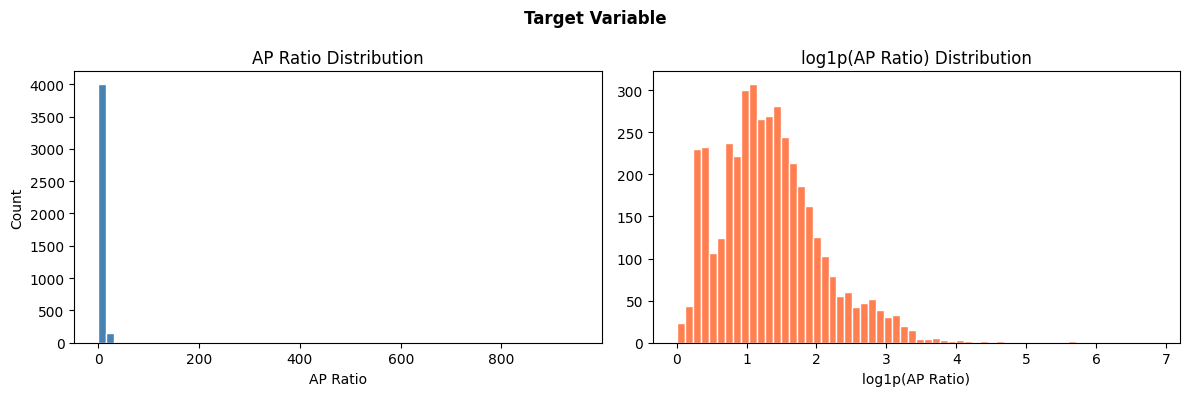

In [37]:
# Target distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(y, bins=60, color="steelblue", edgecolor="white")
ax1.set_title("AP Ratio Distribution")
ax1.set_xlabel("AP Ratio")
ax1.set_ylabel("Count")

ax2.hist(np.log1p(y), bins=60, color="coral", edgecolor="white")
ax2.set_title("log1p(AP Ratio) Distribution")
ax2.set_xlabel("log1p(AP Ratio)")

plt.suptitle("Target Variable", fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Train / Validation / Test Splits

| Split | Train | Val | Test | Design |
|---|---|---|---|---|
| **Random** | 70% | 15% | 15% | i.i.d. rows |
| **Spatial OOD** | 70% districts | 15% districts | 15% districts | Disjoint district sets |
| **Temporal OOD** | Rabi (~28%) | Kharif 1 (~34%) | Kharif 2 (~38%) | Agronomic season order |

The Temporal OOD proportions deviate from 70/15/15 by design — each season is a  
fully disjoint temporal partition mirroring climate-aware forecasting evaluations.


In [38]:
SEED = 42

# A. Random 70 / 15 / 15
X_tr_r, X_tmp, y_tr_r, y_tmp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_val_r, X_te_r, y_val_r, y_te_r = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED)

print("Random Split")
print(f"  Train : {len(X_tr_r):>4}  ({len(X_tr_r)/len(X)*100:.1f}%)")
print(f"  Val   : {len(X_val_r):>4}  ({len(X_val_r)/len(X)*100:.1f}%)")
print(f"  Test  : {len(X_te_r):>4}  ({len(X_te_r)/len(X)*100:.1f}%)")


Random Split
  Train : 2933  (70.0%)
  Val   :  628  (15.0%)
  Test  :  629  (15.0%)


In [39]:
# B. Spatial OOD — disjoint districts
all_districts = df["District"].unique().copy()
np.random.shuffle(all_districts)

n_d = len(all_districts)
n_tr_d = int(0.70 * n_d)
n_val_d = int(0.15 * n_d)

train_districts = set(all_districts[:n_tr_d])
val_districts = set(all_districts[n_tr_d : n_tr_d + n_val_d])
test_districts = set(all_districts[n_tr_d + n_val_d :])

mask_tr_s = df["District"].isin(train_districts)
mask_val_s = df["District"].isin(val_districts)
mask_te_s = df["District"].isin(test_districts)

X_tr_s, y_tr_s = X[mask_tr_s.values], y[mask_tr_s.values]
X_val_s, y_val_s = X[mask_val_s.values], y[mask_val_s.values]
X_te_s, y_te_s = X[mask_te_s.values], y[mask_te_s.values]

print("Spatial OOD Split")
print(f"  Train districts : {len(train_districts)}  →  {len(X_tr_s):>4} rows  ({len(X_tr_s)/len(X)*100:.1f}%)")
print(f"  Val   districts : {len(val_districts)}   →  {len(X_val_s):>4} rows  ({len(X_val_s)/len(X)*100:.1f}%)")
print(f"  Test  districts : {len(test_districts)}   →  {len(X_te_s):>4} rows  ({len(X_te_s)/len(X)*100:.1f}%)")


Spatial OOD Split
  Train districts : 44  →  2879 rows  (68.7%)
  Val   districts : 9   →   587 rows  (14.0%)
  Test  districts : 11   →   724 rows  (17.3%)


In [40]:
# C. Temporal OOD — season-as-time
#
# Bangladesh agronomic calendar (no year column in dataset):
#   Rabi     (winter/dry,   Nov–Mar)  → EARLIEST  → Train
#   Kharif 1 (pre-monsoon, Mar–Jul)   → MID       → Validation
#   Kharif 2 (monsoon,     Jun–Nov)   → LATEST    → Test
#
# The model is trained on dry-season crops and evaluated on monsoon-season crops -
# a genuine distributional shift in temperature, humidity, and crop profile.

mask_tr_t  = df["season_temporal"] == 0   # Rabi
mask_val_t = df["season_temporal"] == 1   # Kharif 1
mask_te_t  = df["season_temporal"] == 2   # Kharif 2

X_tr_t, y_tr_t  = X[mask_tr_t.values], y[mask_tr_t.values]
X_val_t, y_val_t = X[mask_val_t.values], y[mask_val_t.values]
X_te_t, y_te_t  = X[mask_te_t.values], y[mask_te_t.values]

print("Temporal OOD Split (Season-as-Time)")
print(f"  Train - Rabi (season_temporal=0) : {len(X_tr_t):>4} rows  ({len(X_tr_t)/len(X)*100:.1f}%)")
print(f"  Val - Kharif 1 (season_temporal=1) : {len(X_val_t):>4} rows  ({len(X_val_t)/len(X)*100:.1f}%)")
print(f"  Test - Kharif 2 (season_temporal=2) : {len(X_te_t):>4} rows  ({len(X_te_t)/len(X)*100:.1f}%)")


Temporal OOD Split (Season-as-Time)
  Train - Rabi (season_temporal=0) : 1192 rows  (28.4%)
  Val - Kharif 1 (season_temporal=1) : 1420 rows  (33.9%)
  Test - Kharif 2 (season_temporal=2) : 1578 rows  (37.7%)


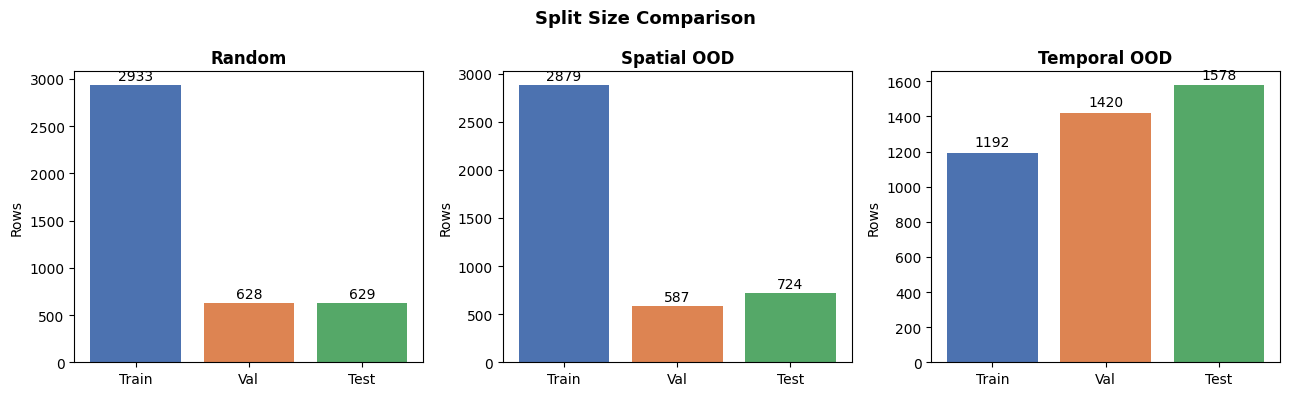

In [41]:
# Split size visualisation
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
split_info = [
    ("Random", [len(X_tr_r), len(X_val_r), len(X_te_r)]),
    ("Spatial OOD", [len(X_tr_s), len(X_val_s), len(X_te_s)]),
    ("Temporal OOD", [len(X_tr_t), len(X_val_t), len(X_te_t)]),
]
colors = ["#4C72B0", "#DD8452", "#55A868"]
labels = ["Train", "Val", "Test"]

for ax, (title, sizes) in zip(axes, split_info):
    bars = ax.bar(labels, sizes, color=colors)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Rows")
    for bar, sz in zip(bars, sizes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(sz), ha="center", va="bottom", fontsize=10)

plt.suptitle("Split Size Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Feature Scaling

In [42]:
def scale_split(X_tr, X_val, X_te):
    """Fit scaler on train only; transform val and test."""
    scaler = StandardScaler()
    Xs_tr  = pd.DataFrame(scaler.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    Xs_val = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
    Xs_te  = pd.DataFrame(scaler.transform(X_te), columns=X_te.columns, index=X_te.index)
    return Xs_tr, Xs_val, Xs_te, scaler

Xs_tr_r, Xs_val_r, Xs_te_r, scaler_r = scale_split(X_tr_r, X_val_r, X_te_r)
Xs_tr_s, Xs_val_s, Xs_te_s, scaler_s = scale_split(X_tr_s, X_val_s, X_te_s)
Xs_tr_t, Xs_val_t, Xs_te_t, scaler_t = scale_split(X_tr_t, X_val_t, X_te_t)

print("Scaling complete - fitted on each split's training fold independently.")


Scaling complete - fitted on each split's training fold independently.


## 8. Model Training & Evaluation

In [58]:
def compute_metrics(y_true, y_pred, label=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"    {label:<8}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}  MAPE={mape:.2f}%")
    return dict(MAE=mae, RMSE=rmse, R2=r2, MAPE=mape)

def train_and_eval(name, model, Xs_tr, y_tr, Xs_val, y_val, Xs_te, y_te):
    model.fit(Xs_tr, y_tr)
    print(f"  {name}")
    val_m = compute_metrics(y_val, model.predict(Xs_val), "Val")
    test_m = compute_metrics(y_te, model.predict(Xs_te), "Test")
    return model, val_m, test_m

MODELS = {
    "Ridge" : Ridge(alpha=1.0),
    "RF" : RandomForestRegressor(n_estimators=200, max_depth=12, random_state=SEED, n_jobs=-1),
    "ExtraTrees" : ExtraTreesRegressor(n_estimators=200, max_depth=12, random_state=SEED, n_jobs=-1),
    "GBM" : GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=SEED),
    "XGBoost" : XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=SEED, verbosity=0),
    "LightGBM" : LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=63, random_state=SEED, verbosity=-1),
}


### 8.1 Random Split

In [44]:
# Check for NaN values after feature engineering
nan_summary = X.isnull().sum()
print(nan_summary)
nan_cols = nan_summary[nan_summary > 0]

if len(nan_cols) > 0:
    print("Columns with NaN values:")
    print(nan_summary[nan_summary > 0])
    print(f"\nTotal NaN cells: {X.isnull().sum().sum()}")
else:
    print("No NaN values found!")

print(X.head())

Area                   0
area_log               0
Avg Temp               0
Avg Humidity           0
Max Temp               0
Min Temp               0
Humidity Min           0
Humidity Max           0
Humidity Range         0
temp_diurnal_range     0
temp_mean              0
gdd_proxy              0
svp_proxy              0
vpd_proxy              0
humidity_mid           0
transplant_month       0
growth_start_month     0
harvest_start_month    0
season_temporal        0
season_sin             0
season_cos             0
area_x_diurnal         0
temp_x_humidity        0
Season_enc             0
Crop Name_enc          0
Transplant_enc         0
Growth_enc             0
Harvest_enc            0
District_enc           0
dtype: int64
No NaN values found!
     Area   area_log  Avg Temp  Avg Humidity  Max Temp  Min Temp  \
0  177321  12.085723      26.0          72.5        40      12.0   
1   25646  10.152182      26.0          72.5        40      12.0   
2  231401  12.351912      26.0       

In [59]:
print("RANDOM SPLIT")
random_results = {}
for name, model in MODELS.items():
    m, val_m, test_m = train_and_eval(name, deepcopy(model),
                                      Xs_tr_r, y_tr_r,
                                      Xs_val_r, y_val_r,
                                      Xs_te_r,  y_te_r)
    random_results[name] = dict(model=m, val=val_m, test=test_m)


RANDOM SPLIT
  Ridge
    Val       MAE=4.3300  RMSE=11.1953  R²=0.1545  MAPE=19391316276312448.00%
    Test      MAE=4.3862  RMSE=7.5795  R²=0.0079  MAPE=1657240181004431.25%
  RF
    Val       MAE=2.4287  RMSE=10.6678  R²=0.2323  MAPE=11503829811548096.00%
    Test      MAE=2.3744  RMSE=7.6653  R²=-0.0147  MAPE=1278590896351786.25%
  ExtraTrees
    Val       MAE=2.2458  RMSE=9.8303  R²=0.3481  MAPE=11040593998568920.00%
    Test      MAE=2.3153  RMSE=8.2008  R²=-0.1615  MAPE=1336713696826409.00%
  GBM
    Val       MAE=2.1716  RMSE=8.3552  R²=0.5291  MAPE=14085615771201618.00%
    Test      MAE=2.3517  RMSE=8.1988  R²=-0.1609  MAPE=976378015071574.62%
  XGBoost
    Val       MAE=2.2627  RMSE=9.0548  R²=0.4469  MAPE=11462184652899228.00%
    Test      MAE=2.5922  RMSE=9.1582  R²=-0.4485  MAPE=443241734537413.38%
  LightGBM
    Val       MAE=2.6627  RMSE=9.7744  R²=0.3555  MAPE=10177468646545340.00%
    Test      MAE=2.8145  RMSE=8.3714  R²=-0.2103  MAPE=2589471485398450.50%


### 8.2 Spatial OOD Split

In [60]:
print("SPATIAL OOD SPLIT")
spatial_results = {}
for name, model in MODELS.items():
    m, val_m, test_m = train_and_eval(name, deepcopy(model),
                                      Xs_tr_s, y_tr_s,
                                      Xs_val_s, y_val_s,
                                      Xs_te_s,  y_te_s)
    spatial_results[name] = dict(model=m, val=val_m, test=test_m)


SPATIAL OOD SPLIT
  Ridge
    Val       MAE=4.4179  RMSE=11.6165  R²=0.1441  MAPE=349902090986676.88%
    Test      MAE=4.3268  RMSE=7.9158  R²=0.2738  MAPE=8969516578064588.00%
  RF
    Val       MAE=2.3746  RMSE=12.0718  R²=0.0757  MAPE=1259328601278838.50%
    Test      MAE=4.2052  RMSE=34.7601  R²=-13.0036  MAPE=4210716528229211.50%
  ExtraTrees
    Val       MAE=2.5401  RMSE=13.9063  R²=-0.2266  MAPE=759583649742936.38%
    Test      MAE=4.8460  RMSE=46.2345  R²=-23.7750  MAPE=5175173774714271.00%
  GBM
    Val       MAE=2.5444  RMSE=11.7273  R²=0.1277  MAPE=8654356423482467.00%
    Test      MAE=5.3536  RMSE=51.0997  R²=-29.2633  MAPE=6356838076260813.00%
  XGBoost
    Val       MAE=2.6344  RMSE=12.1699  R²=0.0606  MAPE=3290121283850011.00%
    Test      MAE=4.6153  RMSE=47.1830  R²=-24.8019  MAPE=4874428633029283.00%
  LightGBM
    Val       MAE=2.6362  RMSE=10.9311  R²=0.2421  MAPE=2072792521003391.50%
    Test      MAE=3.0895  RMSE=14.2292  R²=-1.3466  MAPE=5319650979422059.00

### 8.3 Temporal OOD Split

In [61]:
print("TEMPORAL OOD SPLIT (Rabi → Kharif 1 → Kharif 2)")
temporal_results = {}
for name, model in MODELS.items():
    m, val_m, test_m = train_and_eval(name, deepcopy(model),
                                      Xs_tr_t, y_tr_t,
                                      Xs_val_t, y_val_t,
                                      Xs_te_t,  y_te_t)
    temporal_results[name] = dict(model=m, val=val_m, test=test_m)


TEMPORAL OOD SPLIT (Rabi → Kharif 1 → Kharif 2)
  Ridge
    Val       MAE=8.3208  RMSE=31.3793  R²=-0.0856  MAPE=209.33%
    Test      MAE=3.9940  RMSE=5.8494  R²=-0.6549  MAPE=6786902130184959.00%
  RF
    Val       MAE=6.7369  RMSE=30.7755  R²=-0.0443  MAPE=110.07%
    Test      MAE=3.2579  RMSE=5.3287  R²=-0.3734  MAPE=8801863508779066.00%
  ExtraTrees
    Val       MAE=6.4933  RMSE=30.7107  R²=-0.0399  MAPE=101.04%
    Test      MAE=2.7741  RMSE=4.9443  R²=-0.1823  MAPE=5058300988259423.00%
  GBM
    Val       MAE=6.8539  RMSE=30.8518  R²=-0.0494  MAPE=115.09%
    Test      MAE=3.1978  RMSE=5.4030  R²=-0.4119  MAPE=7950165516201203.00%
  XGBoost
    Val       MAE=6.6048  RMSE=30.7761  R²=-0.0443  MAPE=98.35%
    Test      MAE=3.2357  RMSE=5.3616  R²=-0.3903  MAPE=8801723370842234.00%
  LightGBM
    Val       MAE=6.9861  RMSE=30.8399  R²=-0.0486  MAPE=119.29%
    Test      MAE=3.3630  RMSE=5.4467  R²=-0.4349  MAPE=10229861045789132.00%


## 9. Consolidated Results

In [62]:
def to_df(results_dict, split_name):
    rows = []
    for name, d in results_dict.items():
        for stage in ("val", "test"):
            rows.append({"Split": split_name, "Model": name,
                         "Stage": stage.capitalize(), **d[stage]})
    return pd.DataFrame(rows)

all_results = pd.concat([
    to_df(random_results, "Random"),
    to_df(spatial_results, "Spatial OOD"),
    to_df(temporal_results, "Temporal OOD"),
], ignore_index=True)

for c in ["MAE", "RMSE", "R2", "MAPE"]:
    all_results[c] = all_results[c].round(4)

all_results = all_results.sort_values(["Split", "Stage", "RMSE"]).reset_index(drop=True)
print(all_results.to_string(index=False))


       Split      Model Stage    MAE    RMSE       R2         MAPE
      Random      Ridge  Test 4.3862  7.5795   0.0079 1.657240e+15
      Random         RF  Test 2.3744  7.6653  -0.0147 1.278591e+15
      Random        GBM  Test 2.3517  8.1988  -0.1609 9.763780e+14
      Random ExtraTrees  Test 2.3153  8.2008  -0.1615 1.336714e+15
      Random   LightGBM  Test 2.8145  8.3714  -0.2103 2.589471e+15
      Random    XGBoost  Test 2.5922  9.1582  -0.4485 4.432417e+14
      Random        GBM   Val 2.1716  8.3552   0.5291 1.408562e+16
      Random    XGBoost   Val 2.2627  9.0548   0.4469 1.146218e+16
      Random   LightGBM   Val 2.6627  9.7744   0.3555 1.017747e+16
      Random ExtraTrees   Val 2.2458  9.8303   0.3481 1.104059e+16
      Random         RF   Val 2.4287 10.6678   0.2323 1.150383e+16
      Random      Ridge   Val 4.3300 11.1953   0.1545 1.939132e+16
 Spatial OOD      Ridge  Test 4.3268  7.9158   0.2738 8.969517e+15
 Spatial OOD   LightGBM  Test 3.0895 14.2292  -1.3466 5.319651

In [63]:
# Best model per split on Test set
test_df = all_results[all_results["Stage"] == "Test"]
print("Best model per split (Test R²)")
for split in ["Random", "Spatial OOD", "Temporal OOD"]:
    best = test_df[test_df["Split"] == split].sort_values("R2", ascending=False).iloc[0]
    print(f"  {split:<15}  {best['Model']:<12}  R²={best['R2']:.4f}  RMSE={best['RMSE']:.4f}  MAE={best['MAE']:.4f}  MAPE={best['MAPE']:.2f}%")


Best model per split (Test R²)
  Random           Ridge         R²=0.0079  RMSE=7.5795  MAE=4.3862  MAPE=1657240181004431.25%
  Spatial OOD      Ridge         R²=0.2738  RMSE=7.9158  MAE=4.3268  MAPE=8969516578064589.00%
  Temporal OOD     ExtraTrees    R²=-0.1823  RMSE=4.9443  MAE=2.7741  MAPE=5058300988259423.00%


## 10. Visualisations

### 10.1 R² and RMSE Across All Splits

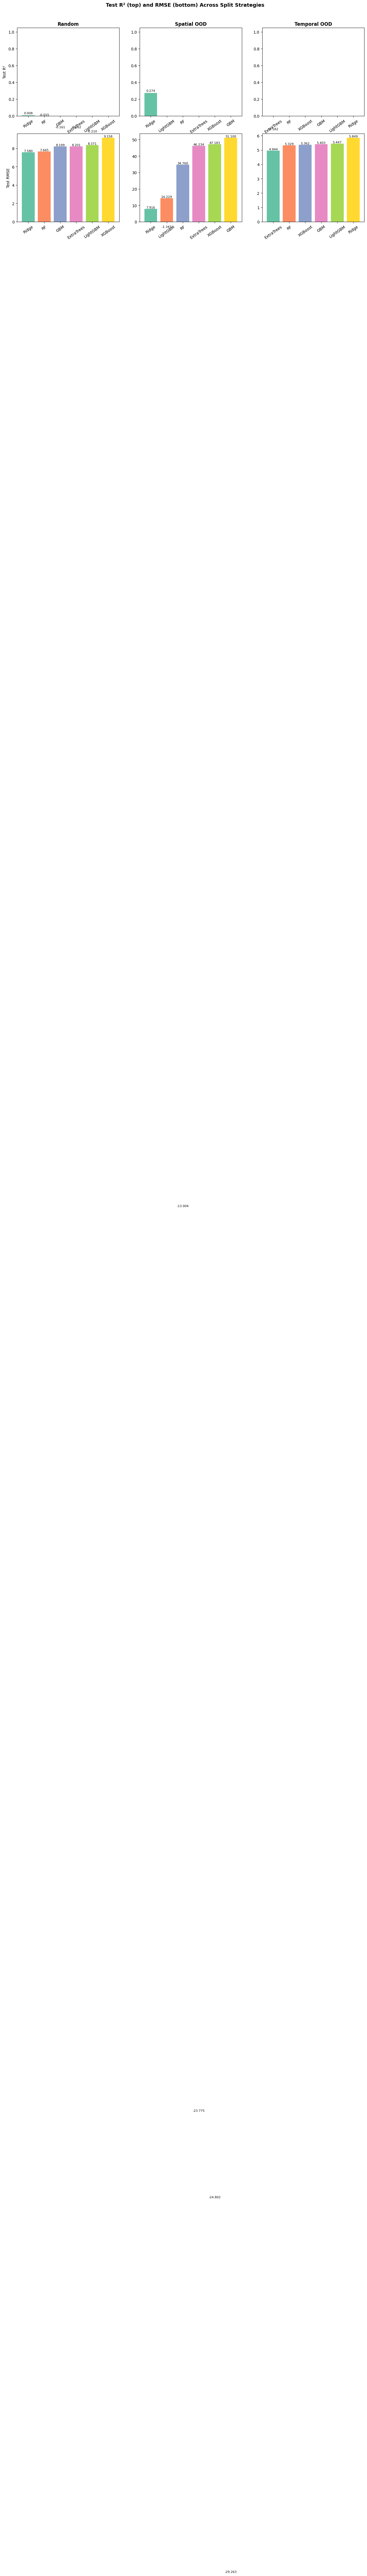

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
splits = ["Random", "Spatial OOD", "Temporal OOD"]
palette = sns.color_palette("Set2", len(MODELS))

for col, split in enumerate(splits):
    sub = test_df[test_df["Split"] == split].sort_values("R2", ascending=False)

    # R² row
    ax = axes[0, col]
    bars = ax.bar(sub["Model"], sub["R2"], color=palette)
    ax.set_title(f"{split}", fontweight="bold")
    ax.set_ylabel("Test R²" if col == 0 else "")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=35)
    for bar, val in zip(bars, sub["R2"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

    # RMSE row
    ax = axes[1, col]
    bars2 = ax.bar(sub["Model"], sub["RMSE"], color=palette)
    ax.set_ylabel("Test RMSE" if col == 0 else "")
    ax.tick_params(axis="x", rotation=35)
    for bar, val in zip(bars2, sub["RMSE"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Test R² (top) and RMSE (bottom) Across Split Strategies", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 10.2 RMSE Heatmap (Model × Split)

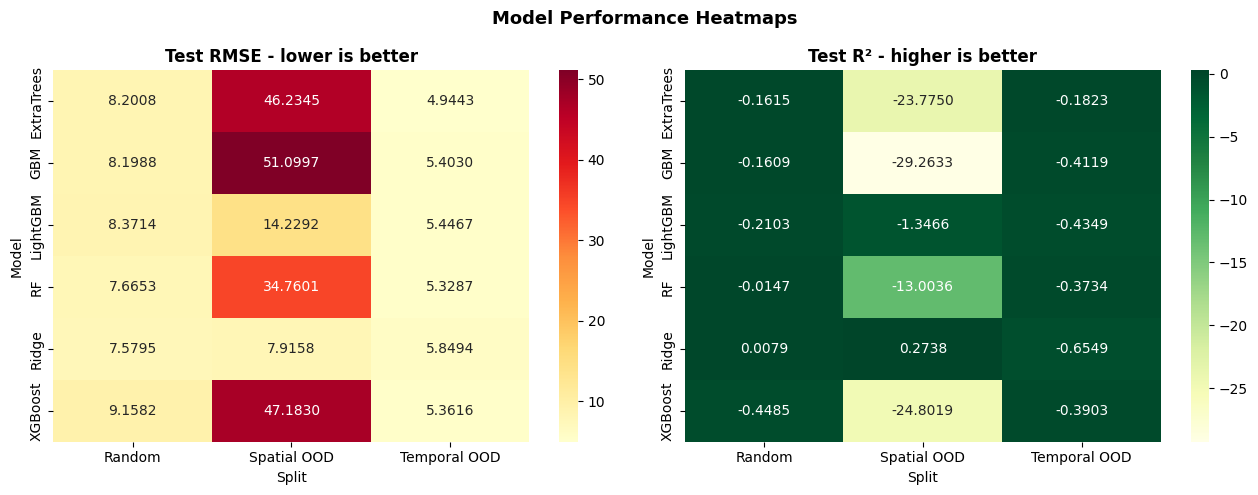

In [68]:
pivot_rmse = test_df.pivot_table(index="Model", columns="Split", values="RMSE")
pivot_r2 = test_df.pivot_table(index="Model", columns="Split", values="R2")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(pivot_rmse, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax1)
ax1.set_title("Test RMSE - lower is better", fontweight="bold")

sns.heatmap(pivot_r2, annot=True, fmt=".4f", cmap="YlGn", ax=ax2)
ax2.set_title("Test R² - higher is better", fontweight="bold")

plt.suptitle("Model Performance Heatmaps", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()


### 10.3 Predicted vs Actual (Best Model, Each Split)

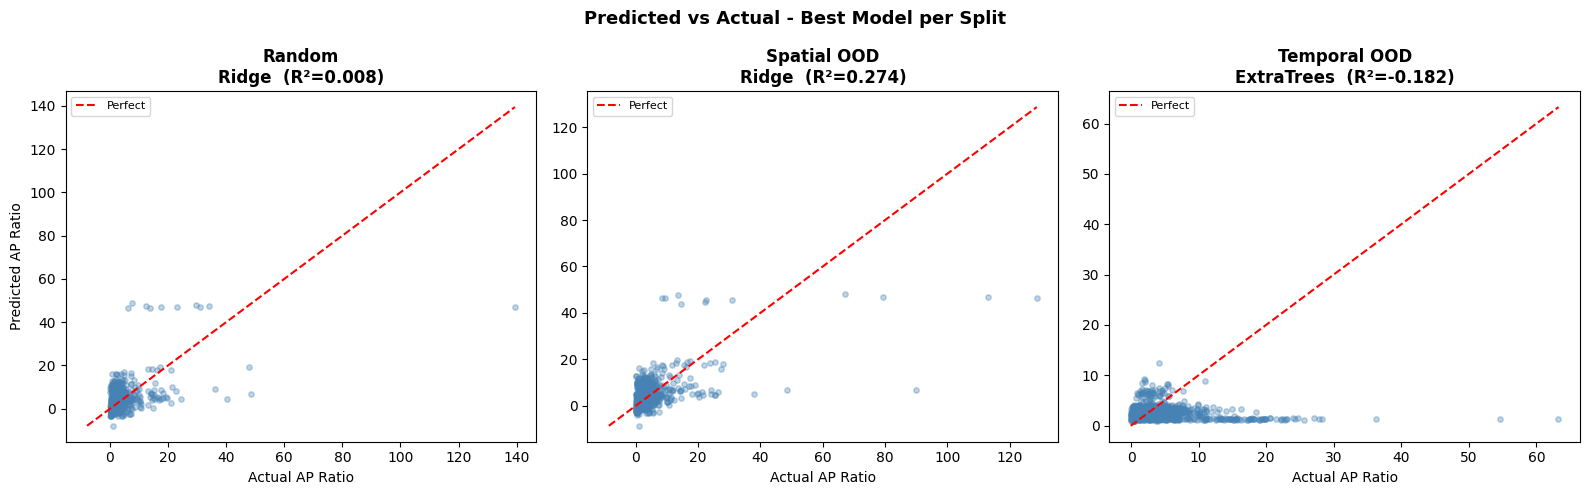

In [69]:
def best_model_name(results, split_results):
    return (test_df[test_df["Split"] == results]
            .sort_values("R2", ascending=False)
            .iloc[0]["Model"])

splits_data = [
    ("Random", random_results, Xs_te_r, y_te_r),
    ("Spatial OOD", spatial_results, Xs_te_s, y_te_s),
    ("Temporal OOD", temporal_results, Xs_te_t, y_te_t),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (split_name, res_dict, Xs_te, y_te) in zip(axes, splits_data):
    bname = best_model_name(split_name, res_dict)
    y_pred = res_dict[bname]["model"].predict(Xs_te)
    r2 = r2_score(y_te, y_pred)

    ax.scatter(y_te, y_pred, alpha=0.35, s=15, color="steelblue")
    lims = [min(y_te.min(), y_pred.min()) - 0.05,
            max(y_te.max(), y_pred.max()) + 0.05]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect")
    ax.set_title(f"{split_name}\n{bname}  (R²={r2:.3f})", fontweight="bold")
    ax.set_xlabel("Actual AP Ratio")
    ax.set_ylabel("Predicted AP Ratio" if ax == axes[0] else "")
    ax.legend(fontsize=8)

plt.suptitle("Predicted vs Actual - Best Model per Split", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


### 10.4 Feature Importance - Best Model (Random Split)

In [71]:
best_name_r = best_model_name("Random", random_results)
best_model_r = random_results[best_name_r]["model"]

if hasattr(best_model_r, "feature_importances_"):
    imp = pd.Series(best_model_r.feature_importances_, index=FEATURE_COLS)
    top20 = imp.nlargest(20).sort_values()

    fig, ax = plt.subplots(figsize=(9, 6))
    colors_imp = ["#2196F3" if "enc" not in f else "#FF9800" for f in top20.index]
    top20.plot(kind="barh", ax=ax, color=colors_imp)
    ax.set_title(f"Top-20 Feature Importances - {best_name_r} (Random Split)", fontweight="bold")
    ax.set_xlabel("Importance")

    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color="#2196F3", label="Engineered / Raw"), Patch(color="#FF9800", label="Categorical Encoded")], loc="lower right")
    plt.tight_layout()
    plt.savefig("../plots/feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"{best_name_r} does not expose feature_importances_")


Ridge does not expose feature_importances_


### 10.5 Residual Analysis (Best Model, All Splits)

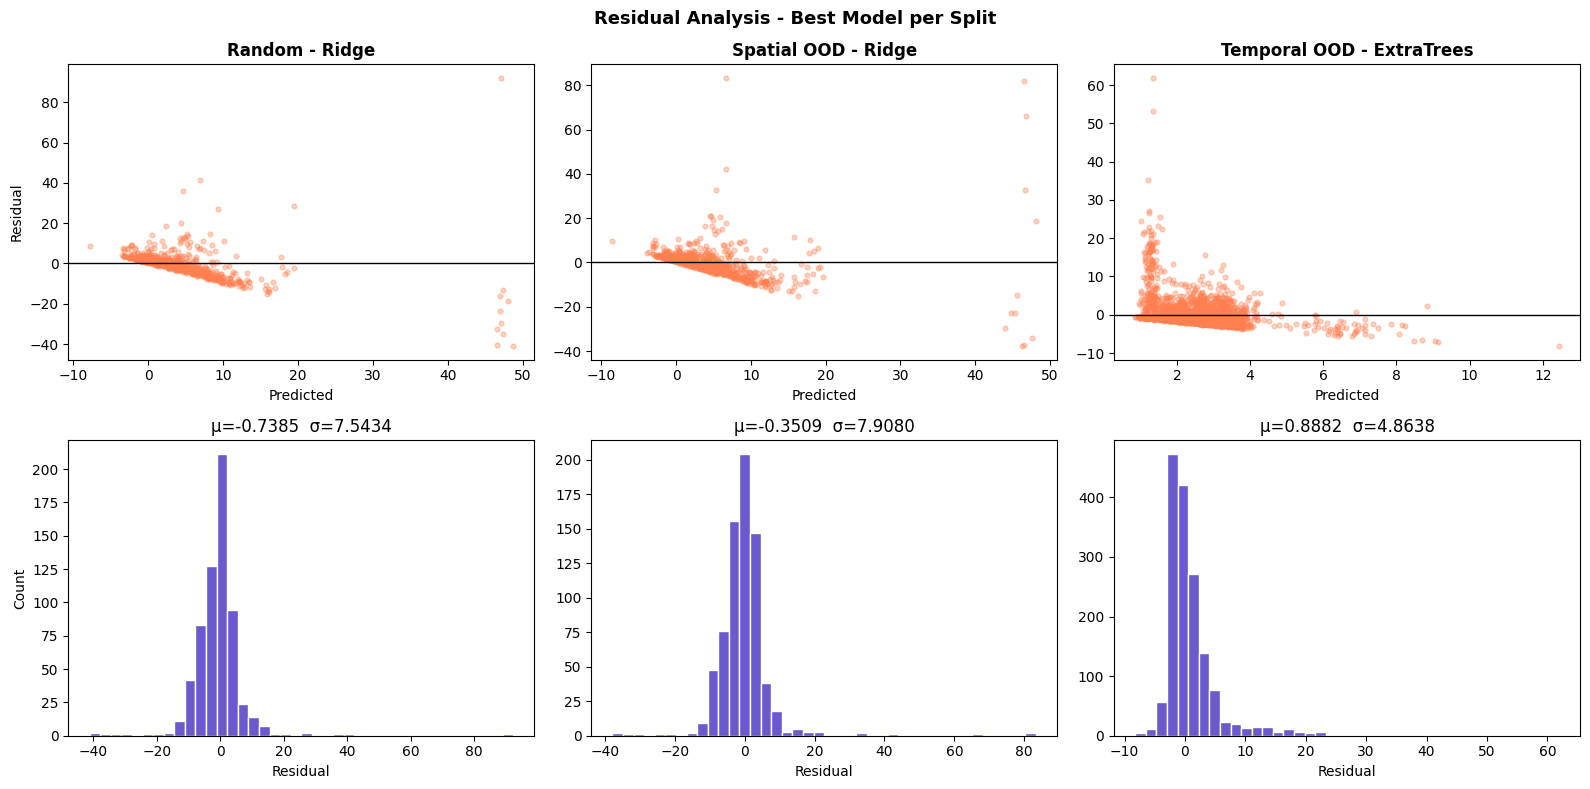

In [72]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col, (split_name, res_dict, Xs_te, y_te) in enumerate(splits_data):
    bname = best_model_name(split_name, res_dict)
    y_pred = res_dict[bname]["model"].predict(Xs_te)
    resid = y_te.values - y_pred

    # Residuals vs predicted
    ax = axes[0, col]
    ax.scatter(y_pred, resid, alpha=0.35, s=12, color="coral")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"{split_name} - {bname}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual" if col == 0 else "")

    # Residual histogram
    ax = axes[1, col]
    ax.hist(resid, bins=40, color="slateblue", edgecolor="white")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count" if col == 0 else "")
    ax.set_title(f"μ={resid.mean():.4f}  σ={resid.std():.4f}")

plt.suptitle("Residual Analysis - Best Model per Split", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/residuals.png", dpi=150, bbox_inches="tight")
plt.show()


### 10.6 Generalisation Gap (Val R² vs Test R²)

In [73]:
gap_rows = []
for split_name, res_dict in [("Random", random_results), ("Spatial OOD", spatial_results), ("Temporal OOD", temporal_results)]:
    for name, d in res_dict.items():
        gap_rows.append({
            "Split" : split_name,
            "Model" : name,
            "Val R²" : round(d["val"]["R2"], 4),
            "Test R²" : round(d["test"]["R2"], 4),
            "Gap (V-T)" : round(d["val"]["R2"] - d["test"]["R2"], 4),
        })

gap_df = pd.DataFrame(gap_rows)
print(gap_df.to_string(index=False))


       Split      Model  Val R²  Test R²  Gap (V-T)
      Random      Ridge  0.1545   0.0079     0.1467
      Random         RF  0.2323  -0.0147     0.2470
      Random ExtraTrees  0.3481  -0.1615     0.5096
      Random        GBM  0.5291  -0.1609     0.6900
      Random    XGBoost  0.4469  -0.4485     0.8954
      Random   LightGBM  0.3555  -0.2103     0.5658
 Spatial OOD      Ridge  0.1441   0.2738    -0.1297
 Spatial OOD         RF  0.0757 -13.0036    13.0793
 Spatial OOD ExtraTrees -0.2266 -23.7750    23.5484
 Spatial OOD        GBM  0.1277 -29.2633    29.3910
 Spatial OOD    XGBoost  0.0606 -24.8019    24.8625
 Spatial OOD   LightGBM  0.2421  -1.3466     1.5887
Temporal OOD      Ridge -0.0856  -0.6549     0.5693
Temporal OOD         RF -0.0443  -0.3734     0.3291
Temporal OOD ExtraTrees -0.0399  -0.1823     0.1425
Temporal OOD        GBM -0.0494  -0.4119     0.3625
Temporal OOD    XGBoost -0.0443  -0.3903     0.3460
Temporal OOD   LightGBM -0.0486  -0.4349     0.3862


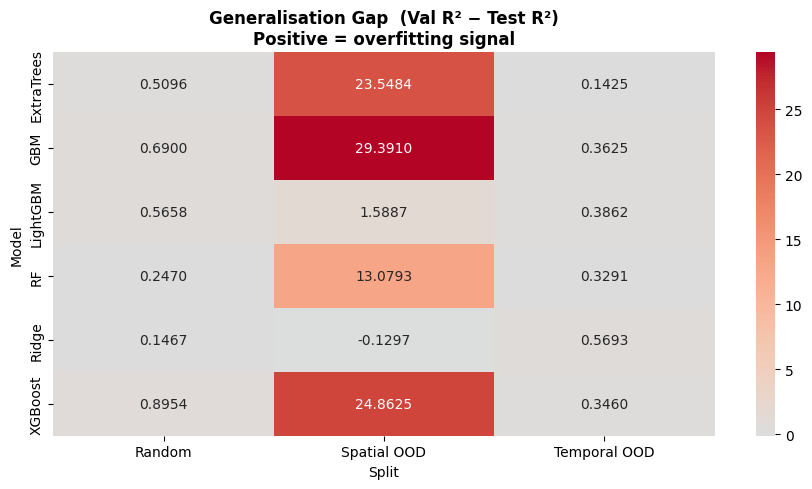

In [74]:
# Gap heatmap
pivot_gap = gap_df.pivot_table(index="Model", columns="Split", values="Gap (V-T)")

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_gap, annot=True, fmt=".4f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Generalisation Gap  (Val R² − Test R²)\nPositive = overfitting signal", fontweight="bold")
plt.tight_layout()
plt.savefig("../plots/gen_gap.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Summary & Recommendations

In [76]:
print("FINAL MODEL RECOMMENDATIONS: ")

for split in ["Random", "Spatial OOD", "Temporal OOD"]:
    sub  = test_df[test_df["Split"] == split].sort_values("R2", ascending=False)
    best = sub.iloc[0]
    print(f"\n  [{split}]")
    print(f"    Best model : {best['Model']}")
    print(f"    Test R² : {best['R2']:.4f}")
    print(f"    Test RMSE : {best['RMSE']:.4f}")
    print(f"    Test MAE : {best['MAE']:.4f}")
    print(f"    Test MAPE : {best['MAPE']:.2f}%")

print()
print(" Interpretation ")
print("  1. Random split reflects best-case i.i.d. performance.")
print("  2. Spatial OOD reflects ability to generalise to new geographic regions / unseen districts.")
print("  3. Temporal OOD reflects ability to generalise across seasons — model trained on Rabi (winter) crops is evaluated on Kharif 2 (monsoon) crops, a genuine distributional shift in climate and crop profile.")
print("  4. Large Random→OOD performance gap signals the model memorises district/season-specific patterns; consider adding more cross-district aggregation features.")


FINAL MODEL RECOMMENDATIONS: 

  [Random]
    Best model : Ridge
    Test R² : 0.0079
    Test RMSE : 7.5795
    Test MAE : 4.3862
    Test MAPE : 1657240181004431.25%

  [Spatial OOD]
    Best model : Ridge
    Test R² : 0.2738
    Test RMSE : 7.9158
    Test MAE : 4.3268
    Test MAPE : 8969516578064589.00%

  [Temporal OOD]
    Best model : ExtraTrees
    Test R² : -0.1823
    Test RMSE : 4.9443
    Test MAE : 2.7741
    Test MAPE : 5058300988259423.00%

 Interpretation 
  1. Random split reflects best-case i.i.d. performance.
  2. Spatial OOD reflects ability to generalise to new geographic regions / unseen districts.
  3. Temporal OOD reflects ability to generalise across seasons — model trained on Rabi (winter) crops is evaluated on Kharif 2 (monsoon) crops, a genuine distributional shift in climate and crop profile.
  4. Large Random→OOD performance gap signals the model memorises district/season-specific patterns; consider adding more cross-district aggregation features.
